In [1]:
import pandas as pd
from matplotlib import pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
df = pd.read_csv("data/throughput.csv").sort_values(["srr_size_MiB", "ebs_throughput"]).reset_index(drop=True)

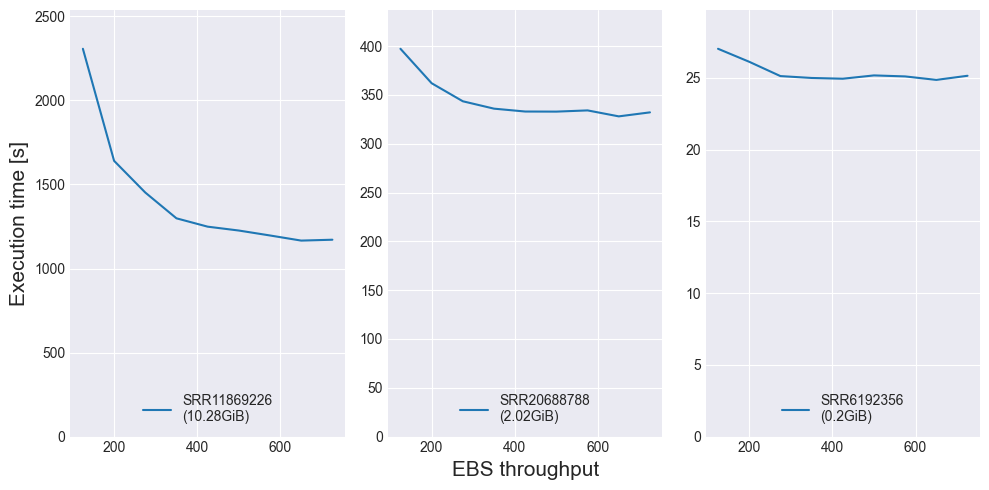

In [3]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 5))

for i, (group_name, group_data) in enumerate(df.groupby("srr_id")):
    ax = axes[i]
    ax.plot(group_data["ebs_throughput"], group_data['execution_time_seconds'], label=f"{group_name}\n({round(group_data['srr_size_MiB'].iloc[0].item() / 1024, 2)}GiB)")
    if i == 0:
        ax.set_ylabel('Execution time [s]', fontsize=15)
    if i == 1:
        ax.set_xlabel('EBS throughput', fontsize=15)

    ax.legend(loc="lower center")

    max_execution_time = group_data['execution_time_seconds'].max()
    ax.set_ylim(0, max_execution_time*1.1)

plt.tight_layout()
plt.savefig("plots/throughput.pdf", format="pdf")
plt.show()